# **Notebook dedicado ao código do trabalho 1 de Análise de Algoritmos**

Artigo: **Aplicação do Problema do Caixeiro Viajante para
determinação de rotas turísticas** (https://ifrs.edu.br/veranopolis/wp-content/uploads/sites/10/2022/04/Artigo-TCC-Ana-Paula-Picolo-2021-Pub.pdf)

## Importação de bibliotecas

In [ ]:
import math                             # cálculos matemáticos
import itertools                        # criação de permutações
import tqdm                             # monitoramento de loops
import time                             # tempo
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## Modelagem do problema do artigo

In [ ]:
# Pontos turísticos de Veranópolis
pontos_mapa = {}

# lista os pontos e adiciona no dicionário
pontos_mapa[1] = {"nome": "Ponte Ernesto Dornelles", 'latitude': -29.044194, "longitude": -51.568478}
pontos_mapa[2] = {"nome": "Belvedere do Espigão", 'latitude': -29.007307, "longitude": -51.547965}
pontos_mapa[3] = {"nome": "Capela São João Batista", 'latitude': -29.027657, "longitude": -51.571733}
pontos_mapa[4] = {"nome": "Grutinha N. Sra. de Lourdes", 'latitude': -28.938485, "longitude": -51.570676}
pontos_mapa[5] = {"nome": "Capela N. Sra de Monte Bérico", 'latitude': -28.966952, "longitude": -51.574488}
pontos_mapa[6] = {"nome": "Cascata da Usina Velha", 'latitude': -28.959960, "longitude": -51.528440}
pontos_mapa[7] = {"nome": "Capitel São Marco", 'latitude': -28.949010, "longitude": -51.583020}
pontos_mapa[8] = {"nome": "Caverna Indígena", 'latitude': -28.966140, "longitude": -51.521020}
pontos_mapa[9] = {"nome": "Torre Mirante da Serra", 'latitude': -28.933860, "longitude": -51.551040}
pontos_mapa[10] = {"nome": "Igreja Medianeira", 'latitude': -28.931520, "longitude": -51.539840}
pontos_mapa[11] = {"nome": "Arco Sul", 'latitude': -28.946390, "longitude": -51.551620}
pontos_mapa[12] = {"nome": "Gruta Nossa Sra. de Lourdes", 'latitude': -28.937366, "longitude": -51.550268}
pontos_mapa[13] = {"nome": "Aeroclube Veranópolis", 'latitude': -28.922050, "longitude": -51.511020}
pontos_mapa[14] = {"nome": "Casa da Cultura", 'latitude': -28.936551, "longitude": -51.548480}
pontos_mapa[15] = {"nome": "Casa Saretta", 'latitude': -28.946124, "longitude": -51.551841}
pontos_mapa[16] = {"nome": "Igreja Matriz São Luiz Gonzaga", 'latitude': -28.935111, "longitude": -51.551652}
pontos_mapa[17] = {"nome": "Portal Monumento", 'latitude': -28.946520, "longitude": -51.551880}
pontos_mapa[18] = {"nome": "Vila Bernardi", 'latitude': -28.938520, "longitude": -51.559040}
pontos_mapa[19] = {"nome": "Arco Norte", 'latitude': -28.921310, "longitude": -51.542820}
pontos_mapa[20] = {"nome": "Balneário Retiro", 'latitude': -28.991050, "longitude": -51.579020}


## Métodos auxiliares

In [ ]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância Euclidiana entre dois pontos (X, Y).

    Entradas:
        ponto 1 (dict): item do dicionário pontos_mapa, contendo as chaves 'latitude' e 'longitude'
        ponto 2 (dict): item do dicionário pontos_mapa, contendo as chaves 'latitude' e 'longitude'

    Saída:
        distancia: float

    Exemplo:
        calcular_distancia_euclidiana(pontos_mapa[1], pontos_mapa[2])

    """
    # raiz quadrada da soma dos quadrados das diferenças entre latitudes e longitudes
    return math.sqrt(
        (ponto1['latitude'] - ponto2['latitude'])**2 +
         (ponto1['longitude'] - ponto2['longitude'])**2
    )

In [ ]:
# testes
print(calcular_distancia_euclidiana({'latitude': 0, 'longitude': 0}, {'latitude': 0, 'longitude': 1}))
print(calcular_distancia_euclidiana(pontos_mapa[1], pontos_mapa[2]))

1.0
0.04220703659344084


In [ ]:
def calcular_custo_rota(mapa_cidades, rota):
    """Calcula o custo total de uma rota informada.

    Entradas:
        mapa_cidades (dict): dicionário contendo todas as cidades mapeadas,
                             contendo as chaves 'latitude' e 'longitude'
        rota (list): lista contendo os pontos a serem considerados no cálculo

    Saída:
        distancia_total: float

    Exemplo:
        calcular_custo_total_rota(pontos_mapa, [1, 2, 3])
    """
    # inicializa variável
    distancia_total = 0

    for i in range(len(rota) - 1):
        distancia_entre_pontos = calcular_distancia_euclidiana(mapa_cidades[rota[i]], mapa_cidades[rota[i+1]])
        # print(f'     Distância entre {mapa_cidades[rota[i]]['nome']} e {mapa_cidades[rota[i+1]]['nome']}: {distancia_entre_pontos}')
        distancia_total += distancia_entre_pontos

    return distancia_total

In [ ]:
# testes
print(calcular_custo_rota(pontos_mapa, [1, 2, 3]))
# print(calcular_custo_rota(pontos_mapa, [5, 7, 1]))

0.07349665666144761


In [ ]:
# testar a função
rotas = [
 [1, 2, 3, 1],
#  [1, 2, 3, 4, 1],
#  [1, 2, 3, 4, 5, 1],
#  [1, 2, 3, 4, 5, 6, 1],
#  [1, 2, 3, 4, 5, 6, 7, 1]
]
for rota in rotas:
    print(f'Custo da rota {rota}: {calcular_custo_rota(pontos_mapa, rota)}')

Custo da rota [1, 2, 3, 1]: 0.0903509556382667


In [ ]:
def plotar_rota_no_mapa(pontos, rota_a_exibir=None):
    """Cria um scatter plot interativo exibindo APENAS os pontos ativos ou na rota."""

    # 1. Filtra os IDs que serão exibidos (se rota for None, exibe todos os pontos)
    ids_exibir = rota_a_exibir if rota_a_exibir else list(pontos.keys())

    # 2. Extrai os dados ordenados respeitando apenas os pontos da rota
    nomes = [pontos[p_id]['nome'] for p_id in ids_exibir]
    latitudes = [pontos[p_id]['latitude'] for p_id in ids_exibir]
    longitudes = [pontos[p_id]['longitude'] for p_id in ids_exibir]

    # 3. Configura o comportamento do gráfico (se há rota, fecha o ciclo e desenha linhas)
    if rota_a_exibir:
        longitudes += [longitudes[0]]
        latitudes += [latitudes[0]]
        nomes += [nomes[0]]
        modo_grafico = 'lines+markers+text'         # com linhas
        # ponto inicial tem uma cor diferente dos demais
        cores_dos_pontos = ['blue'] + ['green'] * (len(ids_exibir) - 1)
        cores_dos_pontos += [cores_dos_pontos[0]]
    else:
        modo_grafico = 'markers+text'               # sem linhas
        cores_dos_pontos = ['green'] * len(ids_exibir)
    # print(cores_dos_pontos)

    # 4. Renderização
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=longitudes,
        y=latitudes,
        mode=modo_grafico,
        text=nomes,
        textposition="top right",
        line=dict(color='black', width=2) if rota_a_exibir else None,
        marker=dict(size=10, color=cores_dos_pontos, line=dict(width=1, color='black')),
        hoverinfo='text'
    ))

    # 5. Configuração de layout e escala proporcional
    fig.update_layout(
        # title=f'Pontos Turísticos de Veranópolis \ncusto: {calcular_custo_rota(rota_a_exibir, pontos)}',
        title={
            'text': f'Pontos Turísticos de Veranópolis' + (f' | Custo: {round( calcular_custo_rota(pontos, rota_a_exibir), 4) }' if rota_a_exibir else ''),
            'font': {
                'size': 15
                }
            },
        margin={
            'l': 50,
            'r': 50,
            't': 50,
            'b': 50
        },
        xaxis_title='Longitude', yaxis_title='Latitude',
        width=500, height=500,
        xaxis=dict(scaleanchor="y", scaleratio=1),
        yaxis=dict(constrain="domain", scaleratio=1),
        showlegend=False
    )

    fig.show()


In [ ]:
# plotar_rota_no_mapa(pontos_mapa)
plotar_rota_no_mapa(pontos_mapa, [1, 2, 3])
plotar_rota_no_mapa(pontos_mapa, [3, 5, 7, 9])
# plotar_rota_no_mapa(pontos_mapa, list(pontos_mapa.keys()))

## Algoritmos

### Força Bruta

In [ ]:
def calcular_rota_forca_bruta(mapa_cidades, ponto_inicial = None):
    """
    Calcula a rota mais eficiente usando força bruta.
    Tempo: fatorial de n, onde n é o número de cidades

    Entradas:
        mapa_cidades (dict): dicionário contendo todas as cidades mapeadas,
                             contendo as chaves 'latitude' e 'longitude'
        ponto_inicial (int): ID do ponto inicial da rota

    Saída:
        melhor_rota (list): lista contendo a sequência de IDs com melhor rota encontrada
        melhor_custo (float): custo da melhor rota encontrada

    Exemplo:
        rota, distancia = calcular_rota_forca_bruta(pontos_mapa)
    """

    # obtém os IDs das cidades
    lista_cidades = list(mapa_cidades.keys())
    if ponto_inicial is not None:
        cidade_origem = ponto_inicial
        lista_cidades.remove(ponto_inicial)
        outras_cidades = lista_cidades
    else:
        # começa na primeira cidade do mapa informado
        cidade_origem = lista_cidades[0]
        outras_cidades = lista_cidades[1:]

    # print(f'    -> Ponto de origem: {cidade_origem}')

    melhor_rota = None
    menor_distancia = float('inf')

    # Gera e testa cada permutação das cidades restantes
    for permutacao in itertools.permutations(outras_cidades):
    # for permutacao in tqdm.tqdm(itertools.permutations(outras_cidades)):
        # time.sleep(0.01)
        # print(f'     -> Permutação: {permutacao}')
        rota_atual = [cidade_origem] + list(permutacao) + [cidade_origem]
        distancia_atual = calcular_custo_rota(mapa_cidades, rota_atual)
        # print(f'     -> Distância: {distancia_atual}')

        if distancia_atual < menor_distancia:
            menor_distancia = distancia_atual
            melhor_rota = rota_atual
            # print(f'     -> menor distância encontrada: {menor_distancia}, nova rota: {melhor_rota}')

    # Retorna a melhor rota encontrada e a menor distância
    return melhor_rota, menor_distancia


In [ ]:
# # testes
# melhor_rota, menor_distancia = calcular_rota_forca_bruta(pontos_mapa)
# melhor_rota, menor_distancia = calcular_rota_forca_bruta(pontos_mapa, 1)
# melhor_rota, menor_distancia = calcular_rota_forca_bruta(pontos_mapa, 3)
# print(f'Melhor rota: {[pontos_mapa[id]['nome'] for id in melhor_rota]}')
# print(f'Menor distância: {menor_distancia}')

In [ ]:
# plotar_rota_no_mapa(pontos_mapa, melhor_rota)

### Vizinho mais próximo

In [ ]:
def calcular_rota_vizinho_mais_proximo(mapa_cidades, ponto_inicial=None):
    """
    Resolve o TSP usando a heurística do Vizinho Mais Próximo, que
    escolhe sempre a cidade mais perto que ainda não foi visitada.

    Entradas:
        mapa_cidades (dict): dicionário contendo todas as cidades mapeadas,
                             contendo as chaves 'latitude' e 'longitude'
        ponto_inicial (int): ID do ponto inicial da rota

    Saída:
        melhor_rota (list): lista contendo a sequência de IDs com melhor rota encontrada
        melhor_custo (float): custo da melhor rota encontrada

    Exemplo:
        rota, distancia = calcular_rota_vizinho_mais_proximo(pontos_mapa)

    """

    # obtém os IDs das cidades
    lista_cidades = list(mapa_cidades.keys())
    if ponto_inicial is not None:
        # começa no ponto escolhido
        cidade_origem = ponto_inicial
    else:
        # começa na primeira cidade do mapa informado
        cidade_origem = lista_cidades[0]

    # Inicializa as listas de controle
    cidades_nao_visitadas = list(lista_cidades)
    cidade_atual = cidade_origem
    melhor_rota = [cidade_atual]
    cidades_nao_visitadas.remove(cidade_origem)

    # Loop para enquanto houver cidades para visitar
    while cidades_nao_visitadas:
        proxima_cidade = None
        menor_distancia_local = float('inf')

        # Procura a cidade mais próxima na vizinhança
        for cidade_candidata in cidades_nao_visitadas:
            dist = calcular_distancia_euclidiana(mapa_cidades[cidade_atual], mapa_cidades[cidade_candidata])

            if dist < menor_distancia_local:
                menor_distancia_local = dist
                proxima_cidade = cidade_candidata

        # remove a cidade identificada da lista de cidades não visitadas
        cidades_nao_visitadas.remove(proxima_cidade)
        # adiciona a cidade identificada na rota
        melhor_rota.append(proxima_cidade)
        # passa para a próxima cidade no loop
        cidade_atual = proxima_cidade

    # adiciona a cidade de origem para fechar a rota
    melhor_rota.append(cidade_origem)

    # Calcula o custo final dessa rota montada de forma gulosa
    distancia_total = calcular_custo_rota(mapa_cidades, melhor_rota)

    return melhor_rota, distancia_total

In [ ]:
# testes
for id_cidade_inicial in [None, 1, 3, 5]:
    melhor_rota, menor_distancia = calcular_rota_vizinho_mais_proximo(pontos_mapa, id_cidade_inicial)
    if id_cidade_inicial is None:
        print(f'Melhor rota: {[pontos_mapa[id]["nome"] for id in melhor_rota]}')
    else:
        print(f'Melhor rota partindo de {id_cidade_inicial}: {[pontos_mapa[id]["nome"] for id in melhor_rota]}')
    print(f'Menor distância: {menor_distancia}\n')
    plotar_rota_no_mapa(pontos_mapa, melhor_rota)

Melhor rota: ['Ponte Ernesto Dornelles', 'Capela São João Batista', 'Belvedere do Espigão', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Ponte Ernesto Dornelles']
Menor distância: 0.43506991347135926



Melhor rota partindo de 1: ['Ponte Ernesto Dornelles', 'Capela São João Batista', 'Belvedere do Espigão', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Ponte Ernesto Dornelles']
Menor distância: 0.43506991347135926



Melhor rota partindo de 3: ['Capela São João Batista', 'Ponte Ernesto Dornelles', 'Belvedere do Espigão', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Capela São João Batista']
Menor distância: 0.43281875860509267



Melhor rota partindo de 5: ['Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico']
Menor distância: 0.4121305785646085



In [ ]:
for id_cidade in list(pontos_mapa.keys()):
    print('\n', '-' * 80)
    melhor_rota, menor_distancia = calcular_rota_vizinho_mais_proximo(pontos_mapa, id_cidade)
    print(f'Melhor rota partindo de {id_cidade} - {pontos_mapa[id_cidade]['nome']}: \n{[pontos_mapa[id]["nome"] for id in melhor_rota]}')
    print(f'Menor distância: {menor_distancia}\n')
    plotar_rota_no_mapa(pontos_mapa, melhor_rota)


 --------------------------------------------------------------------------------
Melhor rota partindo de 1 - Ponte Ernesto Dornelles: 
['Ponte Ernesto Dornelles', 'Capela São João Batista', 'Belvedere do Espigão', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Ponte Ernesto Dornelles']
Menor distância: 0.43506991347135926




 --------------------------------------------------------------------------------
Melhor rota partindo de 2 - Belvedere do Espigão: 
['Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Belvedere do Espigão']
Menor distância: 0.4121305785646085




 --------------------------------------------------------------------------------
Melhor rota partindo de 3 - Capela São João Batista: 
['Capela São João Batista', 'Ponte Ernesto Dornelles', 'Belvedere do Espigão', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Capela São João Batista']
Menor distância: 0.43281875860509267




 --------------------------------------------------------------------------------
Melhor rota partindo de 4 - Grutinha N. Sra. de Lourdes: 
['Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Capitel São Marco', 'Capela N. Sra de Monte Bérico', 'Balneário Retiro', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Grutinha N. Sra. de Lourdes']
Menor distância: 0.46647823966882584




 --------------------------------------------------------------------------------
Melhor rota partindo de 5 - Capela N. Sra de Monte Bérico: 
['Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Balneário Retiro', 'Capela N. Sra de Monte Bérico']
Menor distância: 0.4121305785646085



...


 --------------------------------------------------------------------------------
Melhor rota partindo de 16 - Igreja Matriz São Luiz Gonzaga: 
['Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Vila Bernardi', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Grutinha N. Sra. de Lourdes', 'Capitel São Marco', 'Capela N. Sra de Monte Bérico', 'Balneário Retiro', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Caverna Indígena', 'Cascata da Usina Velha', 'Aeroclube Veranópolis', 'Igreja Matriz São Luiz Gonzaga']
Menor distância: 0.4119924191074852




 --------------------------------------------------------------------------------
Melhor rota partindo de 17 - Portal Monumento: 
['Portal Monumento', 'Arco Sul', 'Casa Saretta', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Vila Bernardi', 'Grutinha N. Sra. de Lourdes', 'Capitel São Marco', 'Capela N. Sra de Monte Bérico', 'Balneário Retiro', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Caverna Indígena', 'Cascata da Usina Velha', 'Igreja Medianeira', 'Arco Norte', 'Aeroclube Veranópolis', 'Portal Monumento']
Menor distância: 0.4027936980209478




 --------------------------------------------------------------------------------
Melhor rota partindo de 18 - Vila Bernardi: 
['Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Grutinha N. Sra. de Lourdes', 'Capitel São Marco', 'Capela N. Sra de Monte Bérico', 'Balneário Retiro', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Caverna Indígena', 'Cascata da Usina Velha', 'Aeroclube Veranópolis', 'Vila Bernardi']
Menor distância: 0.4204980651227431




 --------------------------------------------------------------------------------
Melhor rota partindo de 19 - Arco Norte: 
['Arco Norte', 'Igreja Medianeira', 'Casa da Cultura', 'Gruta Nossa Sra. de Lourdes', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Vila Bernardi', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Grutinha N. Sra. de Lourdes', 'Capitel São Marco', 'Capela N. Sra de Monte Bérico', 'Balneário Retiro', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Caverna Indígena', 'Cascata da Usina Velha', 'Aeroclube Veranópolis', 'Arco Norte']
Menor distância: 0.38578660002724857




 --------------------------------------------------------------------------------
Melhor rota partindo de 20 - Balneário Retiro: 
['Balneário Retiro', 'Capela N. Sra de Monte Bérico', 'Capitel São Marco', 'Grutinha N. Sra. de Lourdes', 'Vila Bernardi', 'Igreja Matriz São Luiz Gonzaga', 'Torre Mirante da Serra', 'Gruta Nossa Sra. de Lourdes', 'Casa da Cultura', 'Igreja Medianeira', 'Arco Norte', 'Casa Saretta', 'Arco Sul', 'Portal Monumento', 'Cascata da Usina Velha', 'Caverna Indígena', 'Aeroclube Veranópolis', 'Belvedere do Espigão', 'Capela São João Batista', 'Ponte Ernesto Dornelles', 'Balneário Retiro']
Menor distância: 0.41213057856460855



## Execução de análise

In [ ]:
import pandas as pd
import random as rnd
import datetime

In [ ]:
# # executa o teste com N pontos turísticos
# rnd.seed(55)
# pontos_selecionados = rnd.sample(list(pontos_mapa.keys()), 8)
# print(pontos_selecionados)

# # mostra os pontos selecionados
# pontos_mapa_selecionados = {id: pontos_mapa[id] for id in pontos_selecionados}
# for p in pontos_mapa_selecionados:
#     print(pontos_mapa_selecionados[p])

In [ ]:
# define quantos pontos serão selecionados para a análise
# números maiores que 10 deixam a análise por força bruta extremamente lenta
NUMERO_MAXIMO_PONTOS_ANALISE = 10
qtd_pontos_selecionar = [i for i in range(2, len(list(pontos_mapa.keys())))]
qtd_pontos_selecionar = qtd_pontos_selecionar[:NUMERO_MAXIMO_PONTOS_ANALISE-1]
print(f'A análise será feita com as quantidades de pontos turísticos: {qtd_pontos_selecionar}.\n')

# executa os algoritmos
resultados = []
for algoritmo in [calcular_rota_forca_bruta, calcular_rota_vizinho_mais_proximo]:

    for qtd_pontos in qtd_pontos_selecionar:

        # seleciona os pontos
        rnd.seed(55)
        pontos_selecionados = rnd.sample(list(pontos_mapa.keys()), qtd_pontos)
        pontos_mapa_selecionados = {id: pontos_mapa[id] for id in pontos_selecionados}
        print(pontos_selecionados)
        # mostra o nome dos pontos selecionados
        for p in pontos_mapa_selecionados:
            print(pontos_mapa_selecionados[p])

        for ponto_inicial in pontos_selecionados:
            print(f'Executando {algoritmo.__name__} com {qtd_pontos} pontos turísticos, iniciando no ponto {ponto_inicial}...', end=' ')

            inicio = time.time()
            # executa o algoritmo
            rota, distancia = algoritmo(mapa_cidades=pontos_mapa_selecionados, ponto_inicial=ponto_inicial)
            fim = time.time()
            diferenca_tempo = round(fim - inicio, 6)
            print(f'Tempo: {diferenca_tempo:.5f}, distância: {distancia:.5f}')

            # registra o resultado
            resultados.append(
                {
                    'qtd_pontos': qtd_pontos,
                    'ponto_inicial': ponto_inicial,
                    'algoritmo': algoritmo.__name__,
                    'melhor_rota': rota,
                    'menor_distancia': round(distancia, 5),
                    'data_hora_inicio': inicio,
                    'data_hora_fim': fim,
                    'tempo_execucao': round(fim - inicio, 5)
                }
            )
        print('-' * 80, '\n')

pd.set_option('float_format', '{:.5f}'.format)
df_resultados = pd.DataFrame(resultados)
df_resultados

A análise será feita com as quantidades de pontos turísticos: [2, 3, 4, 5, 6, 7, 8, 9, 10].

[3, 7]
{'nome': 'Capela São João Batista', 'latitude': -29.027657, 'longitude': -51.571733}
{'nome': 'Capitel São Marco', 'latitude': -28.94901, 'longitude': -51.58302}
Executando calcular_rota_forca_bruta com 2 pontos turísticos, iniciando no ponto 3... Tempo: 0.00012, distância: 0.15891
Executando calcular_rota_forca_bruta com 2 pontos turísticos, iniciando no ponto 7... Tempo: 0.00001, distância: 0.15891
-------------------------------------------------------------------------------- 

[3, 7, 5]
{'nome': 'Capela São João Batista', 'latitude': -29.027657, 'longitude': -51.571733}
{'nome': 'Capitel São Marco', 'latitude': -28.94901, 'longitude': -51.58302}
{'nome': 'Capela N. Sra de Monte Bérico', 'latitude': -28.966952, 'longitude': -51.574488}
Executando calcular_rota_forca_bruta com 3 pontos turísticos, iniciando no ponto 3... Tempo: 0.00006, distância: 0.16009
Executando calcular_rota_forc

,qtd_pontos,ponto_inicial,algoritmo,melhor_rota,menor_distancia,data_hora_inicio,data_hora_fim,tempo_execucao
0,2,3,calcular_rota_forca_bruta,"[3, 7, 3]",0.15891,1781543017.32866,1781543017.32878,0.00012
1,2,7,calcular_rota_forca_bruta,"[7, 3, 7]",0.15891,1781543017.32880,1781543017.32881,0.00001
2,3,3,calcular_rota_forca_bruta,"[3, 7, 5, 3]",0.16009,1781543017.32888,1781543017.32894,0.00005
3,3,7,calcular_rota_forca_bruta,"[7, 3, 5, 7]",0.16009,1781543017.32896,1781543017.32897,0.00001
4,3,5,calcular_rota_forca_bruta,"[5, 3, 7, 5]",0.16009,1781543017.32899,1781543017.32900,0.00001
...,...,...,...,...,...,...,...,...
103,10,12,calcular_rota_vizinho_mais_proximo,"[12, 16, 18, 10, 6, 5, 7, 20, 2, 3, 12]",0.32968,1781543044.88571,1781543044.88574,0.00003
104,10,16,calcular_rota_vizinho_mais_proximo,"[16, 12, 18, 10, 6, 5, 7, 20, 2, 3, 16]",0.33228,1781543044.88575,1781543044.88577,0.00003
105,10,18,calcular_rota_vizinho_mais_proximo,"[18, 16, 12, 10, 6, 5, 7, 20, 2, 3, 18]",0.31843,1781543044.88578,1781543044.88581,0.00003
106,10,2,calcular_rota_vizinho_mais_proximo,"[2, 3, 20, 5, 7, 18, 16, 12, 10, 6, 2]",0.24377,1781543044.88582,1781543044.88585,0.00003


In [ ]:
melhor_rota_forca_bruta = df_resultados[df_resultados['algoritmo'] == 'calcular_rota_forca_bruta'].sort_values(by='menor_distancia', ascending=False).iloc[0]['melhor_rota']
# melhor_rota_forca_bruta
plotar_rota_no_mapa(pontos_mapa, melhor_rota_forca_bruta)

In [ ]:
# resultado 1: como o algoritmo de força bruta garante o melhor resultado, ...
#       ... as distâncias são sempre iguais para cada quantidade de pontos,
#       ... independente de onde começa
#       o máximo que acontece é que os itens da rota verificada estão em outra ordem
df_resultados_grupo = df_resultados[df_resultados['algoritmo'] == 'calcular_rota_forca_bruta']\
    .groupby(['qtd_pontos'])\
    .agg({
        'menor_distancia': ['min', 'max', 'mean'],
        'tempo_execucao': ['min', 'max', 'mean'],
    })\
    .reset_index()
df_resultados_grupo['diff_distancia'] = df_resultados_grupo['menor_distancia']['max'] - df_resultados_grupo['menor_distancia']['min']
df_resultados_grupo['diff_tempo'] = df_resultados_grupo['tempo_execucao']['max'] - df_resultados_grupo['tempo_execucao']['min']
df_resultados_grupo

qtd_pontos menor_distancia                 tempo_execucao                  \
                         min     max    mean            min     max    mean   
0          2         0.15891 0.15891 0.15891        0.00001 0.00012 0.00007   
1          3         0.16009 0.16009 0.16009        0.00001 0.00005 0.00002   
2          4         0.22851 0.22851 0.22851        0.00002 0.00002 0.00002   
3          5         0.22959 0.22959 0.22959        0.00010 0.00547 0.00118   
4          6         0.22972 0.22972 0.22972        0.00038 0.00126 0.00058   
5          7         0.23191 0.23191 0.23191        0.00253 0.00329 0.00276   
6          8         0.23191 0.23191 0.23191        0.02112 0.02599 0.02326   
7          9         0.23814 0.23814 0.23814        0.18354 0.19784 0.18919   
8         10         0.24377 0.24377 0.24377        1.83959 4.96020 2.56304   

  diff_distancia diff_tempo  
                             
0        0.00000    0.00011  
1        0.00000    0.00004  
2        0.00000    0.00000  
3        0.00000    0.00537  
4        0.00000    0.00088  
5        0.00000    0.00076  
6        0.00000    0.00487  
7        0.00000    0.01430  
8        0.00000    3.12061

<Axes: title={'center': 'Força Bruta'}, xlabel='qtd_pontos'>

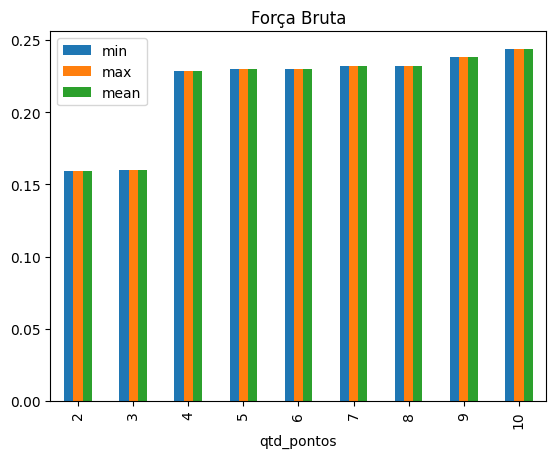

In [ ]:
# não há diferença entre os pontos de origem no cálculo da melhor rota
# mínimo = média = máximo
df_resultados_grupo.plot(kind='bar', x='qtd_pontos', y='menor_distancia', title='Força Bruta')

<Axes: title={'center': 'Força Bruta'}, xlabel='qtd_pontos', ylabel='Tempo (s)'>

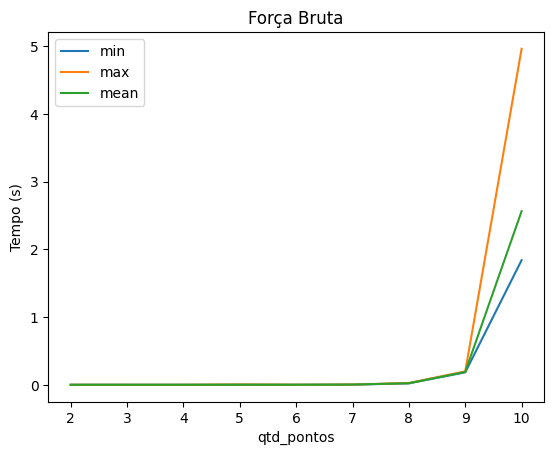

In [ ]:
# já o tempo na execução da força bruta cresce exponencialmente
df_resultados_grupo.plot(kind='line', x='qtd_pontos', y='tempo_execucao', title='Força Bruta', ylabel='Tempo (s)')

In [ ]:
# resultado 2: como o algoritmo de vizinho mais próximo NÃO garante o melhor resultado, ...
#       ... as distâncias PODEM SER DIFERENTES para cada quantidade de pontos, ...
#       ... especialmente quando a quantidade de pontos é maior
df_resultados_grupo = df_resultados[df_resultados['algoritmo'] == 'calcular_rota_vizinho_mais_proximo']\
    .groupby(['qtd_pontos'])\
    .agg({
        'menor_distancia': ['min', 'max', 'mean'],
        'tempo_execucao': ['min', 'max', 'mean'],
    })\
    .reset_index()
df_resultados_grupo['diff_distancia'] = df_resultados_grupo['menor_distancia']['max'] - df_resultados_grupo['menor_distancia']['min']
df_resultados_grupo['diff_tempo'] = df_resultados_grupo['tempo_execucao']['max'] - df_resultados_grupo['tempo_execucao']['min']
df_resultados_grupo

qtd_pontos menor_distancia                 tempo_execucao                  \
                         min     max    mean            min     max    mean   
0          2         0.15891 0.15891 0.15891        0.00001 0.00004 0.00003   
1          3         0.16009 0.16009 0.16009        0.00001 0.00003 0.00002   
2          4         0.22851 0.25017 0.23392        0.00001 0.00001 0.00001   
3          5         0.22959 0.25027 0.23373        0.00001 0.00002 0.00001   
4          6         0.22972 0.23594 0.23187        0.00001 0.00001 0.00001   
5          7         0.23191 0.23814 0.23481        0.00001 0.00002 0.00001   
6          8         0.23191 0.25493 0.24041        0.00002 0.00003 0.00002   
7          9         0.23814 0.28395 0.26342        0.00002 0.00002 0.00002   
8         10         0.24377 0.33228 0.27943        0.00003 0.00003 0.00003   

  diff_distancia diff_tempo  
                             
0        0.00000    0.00003  
1        0.00000    0.00002  
2        0.02166    0.00000  
3        0.02068    0.00001  
4        0.00622    0.00000  
5        0.00623    0.00001  
6        0.02302    0.00001  
7        0.04581    0.00000  
8        0.08851    0.00000

<Axes: title={'center': 'Vizinho mais Próximo'}, xlabel='qtd_pontos'>

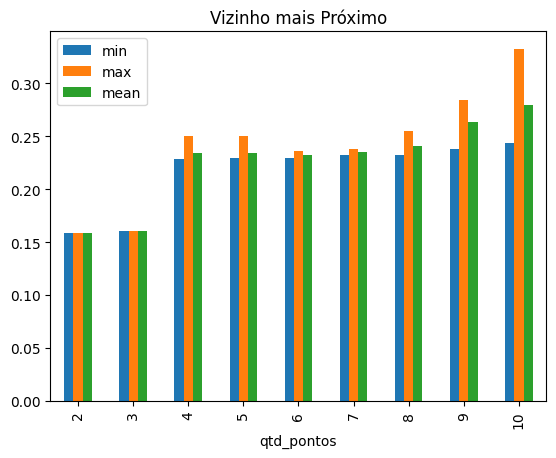

In [ ]:
# no vizinho mais próximo a menor distância pode variar, porque o valor ótimo não é garantido
# mínimo <> máximo => média diferente
df_resultados_grupo.plot(kind='bar', x='qtd_pontos', y='menor_distancia', title='Vizinho mais Próximo')

<Axes: title={'center': 'Vizinho mais Próximo'}, xlabel='qtd_pontos', ylabel='Tempo (s)'>

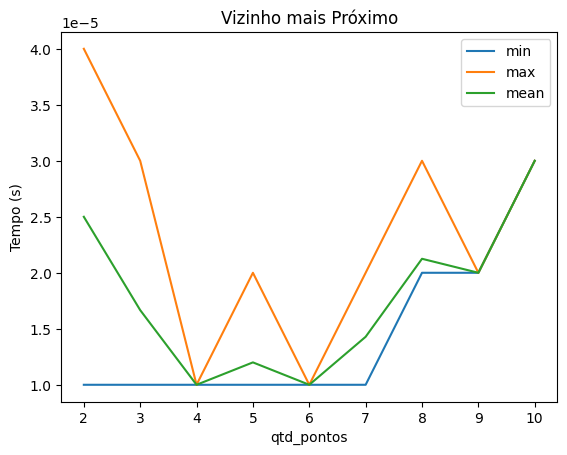

In [ ]:
# já o tempo não cresce exponencialmente independentemente da quantidade de pontos
# variações para cima e para baixo são possíveis no gráfico porque os intervalos de tempo são muito pequenos
df_resultados_grupo.plot(kind='line', x='qtd_pontos', y='tempo_execucao', title='Vizinho mais Próximo', ylabel='Tempo (s)')

In [ ]:
# resultado 3: comparando os algoritmos
df_resultados_grupo = df_resultados\
    .groupby(['algoritmo', 'qtd_pontos'])\
    .agg({
        'menor_distancia': ['min', 'max', 'mean'],
        'tempo_execucao': ['min', 'max', 'mean'],
    })\
    .reset_index()
df_resultados_grupo

algoritmo qtd_pontos menor_distancia          \
                                                              min     max   
0            calcular_rota_forca_bruta          2         0.15891 0.15891   
1            calcular_rota_forca_bruta          3         0.16009 0.16009   
2            calcular_rota_forca_bruta          4         0.22851 0.22851   
3            calcular_rota_forca_bruta          5         0.22959 0.22959   
4            calcular_rota_forca_bruta          6         0.22972 0.22972   
5            calcular_rota_forca_bruta          7         0.23191 0.23191   
6            calcular_rota_forca_bruta          8         0.23191 0.23191   
7            calcular_rota_forca_bruta          9         0.23814 0.23814   
8            calcular_rota_forca_bruta         10         0.24377 0.24377   
9   calcular_rota_vizinho_mais_proximo          2         0.15891 0.15891   
10  calcular_rota_vizinho_mais_proximo          3         0.16009 0.16009   
11  calcular_rota_vizinho_mais_proximo          4         0.22851 0.25017   
12  calcular_rota_vizinho_mais_proximo          5         0.22959 0.25027   
13  calcular_rota_vizinho_mais_proximo          6         0.22972 0.23594   
14  calcular_rota_vizinho_mais_proximo          7         0.23191 0.23814   
15  calcular_rota_vizinho_mais_proximo          8         0.23191 0.25493   
16  calcular_rota_vizinho_mais_proximo          9         0.23814 0.28395   
17  calcular_rota_vizinho_mais_proximo         10         0.24377 0.33228   

           tempo_execucao                  
      mean            min     max    mean  
0  0.15891        0.00001 0.00012 0.00007  
1  0.16009        0.00001 0.00005 0.00002  
2  0.22851        0.00002 0.00002 0.00002  
3  0.22959        0.00010 0.00547 0.00118  
4  0.22972        0.00038 0.00126 0.00058  
5  0.23191        0.00253 0.00329 0.00276  
6  0.23191        0.02112 0.02599 0.02326  
7  0.23814        0.18354 0.19784 0.18919  
8  0.24377        1.83959 4.96020 2.56304  
9  0.15891        0.00001 0.00004 0.00003  
10 0.16009        0.00001 0.00003 0.00002  
11 0.23392        0.00001 0.00001 0.00001  
12 0.23373        0.00001 0.00002 0.00001  
13 0.23187        0.00001 0.00001 0.00001  
14 0.23481        0.00001 0.00002 0.00001  
15 0.24041        0.00002 0.00003 0.00002  
16 0.26342        0.00002 0.00002 0.00002  
17 0.27943        0.00003 0.00003 0.00003

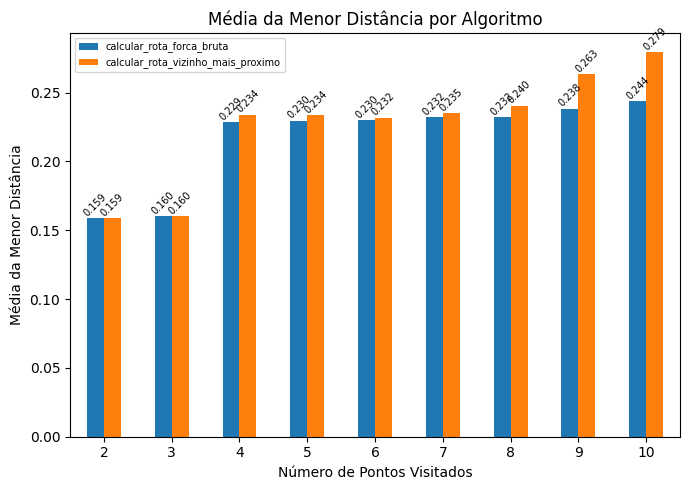

In [ ]:
import matplotlib.pyplot as plt

df_pivot = df_resultados_grupo.pivot(index='qtd_pontos', columns='algoritmo', values=('menor_distancia', 'mean'))
ax = df_pivot.plot(kind='bar', figsize=(7, 5))
plt.title('Média da Menor Distância por Algoritmo')
plt.xlabel('Número de Pontos Visitados')
plt.ylabel('Média da Menor Distância')
plt.xticks(rotation=0)
# adiciona os valores nas colunas
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=7, rotation=45)

plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

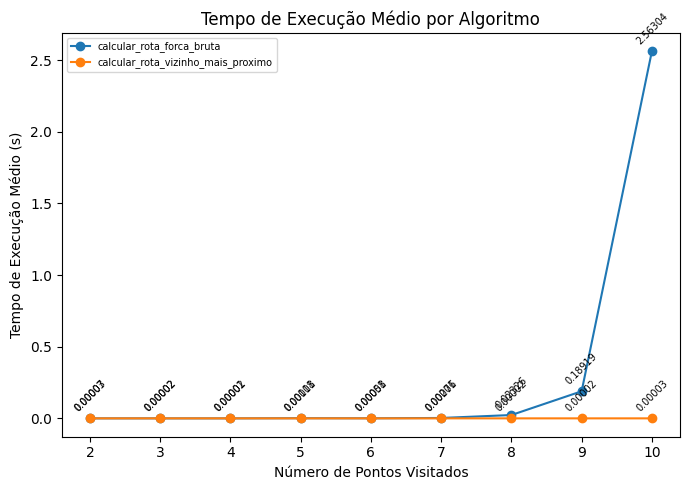

In [ ]:
import matplotlib.pyplot as plt

df_pivot = df_resultados_grupo.pivot(index='qtd_pontos', columns='algoritmo', values=('tempo_execucao', 'mean'))
ax = df_pivot.plot(kind='line', figsize=(7, 5), marker='o') # Adicionado marker='o'
plt.title('Tempo de Execução Médio por Algoritmo')
plt.xlabel('Número de Pontos Visitados')
plt.ylabel('Tempo de Execução Médio (s)')
plt.xticks(rotation=0)

# Adiciona os valores aos pontos de dados
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        # Ajuste de formato para exibir 5 casas decimais
        ax.annotate(f'{y:.5f}', (x, y), textcoords="offset points", xytext=(0,5), ha='center', fontsize=7, rotation=45)

plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

# o tempo de execução do algoritmo de força bruta cresce exponencialmente enquanto ...
# ... o tempo de execução do vizinho mais próximo praticamente não aumenta

In [ ]:
# explorando o resultado com o número máximo de pontos visitados
df_resultados_grupo = df_resultados[df_resultados['qtd_pontos'] == NUMERO_MAXIMO_PONTOS_ANALISE]
df_resultados_grupo

,qtd_pontos,ponto_inicial,algoritmo,melhor_rota,menor_distancia,data_hora_inicio,data_hora_fim,tempo_execucao
44,10,3,calcular_rota_forca_bruta,"[3, 20, 5, 7, 18, 16, 12, 10, 6, 2, 3]",0.24377,1781543019.25055,1781543022.13475,2.88420
45,10,7,calcular_rota_forca_bruta,"[7, 5, 20, 3, 2, 6, 10, 12, 16, 18, 7]",0.24377,1781543022.13509,1781543024.58066,2.44557
46,10,5,calcular_rota_forca_bruta,"[5, 7, 18, 16, 12, 10, 6, 2, 3, 20, 5]",0.24377,1781543024.58091,1781543026.44876,1.86785
47,10,10,calcular_rota_forca_bruta,"[10, 12, 16, 18, 7, 5, 20, 3, 2, 6, 10]",0.24377,1781543026.44901,1781543028.46182,2.01281
48,10,20,calcular_rota_forca_bruta,"[20, 3, 2, 6, 10, 12, 16, 18, 7, 5, 20]",0.24377,1781543028.46210,1781543030.36230,1.90020
49,10,12,calcular_rota_forca_bruta,"[12, 16, 18, 7, 5, 20, 3, 2, 6, 10, 12]",0.24377,1781543030.36259,1781543035.32278,4.96020
50,10,16,calcular_rota_forca_bruta,"[16, 12, 10, 6, 2, 3, 20, 5, 7, 18, 16]",0.24377,1781543035.32303,1781543039.24990,3.92688
51,10,18,calcular_rota_forca_bruta,"[18, 7, 5, 20, 3, 2, 6, 10, 12, 16, 18]",0.24377,1781543039.25019,1781543041.13707,1.88689
52,10,2,calcular_rota_forca_bruta,"[2, 3, 20, 5, 7, 18, 16, 12, 10, 6, 2]",0.24377,1781543041.13731,1781543043.04357,1.90625
53,10,6,calcular_rota_forca_bruta,"[6, 10, 12, 16, 18, 7, 5, 20, 3, 2, 6]",0.24377,1781543043.04383,1781543044.88342,1.83959


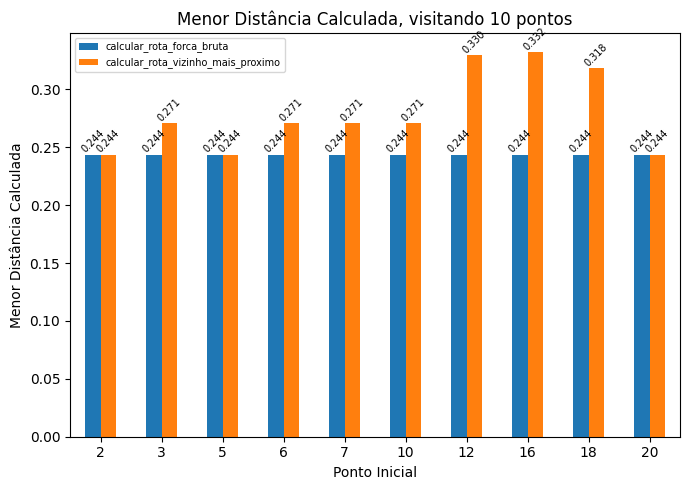

In [ ]:
import matplotlib.pyplot as plt

df_pivot = df_resultados_grupo.pivot(index='ponto_inicial', columns='algoritmo', values=('menor_distancia'))
ax = df_pivot.plot(kind='bar', figsize=(7, 5))
plt.title(f'Menor Distância Calculada, visitando {NUMERO_MAXIMO_PONTOS_ANALISE} pontos')
plt.xlabel('Ponto Inicial')
plt.ylabel('Menor Distância Calculada')
plt.xticks(rotation=0)
# adiciona os valores nas colunas
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=7, rotation=45)

plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

# a menor distância calculada é fixa para o algoritmo de força bruta, independente do ponto inicial
# já para o algoritmo vizinho mais próximo, a menor distância não é garantida

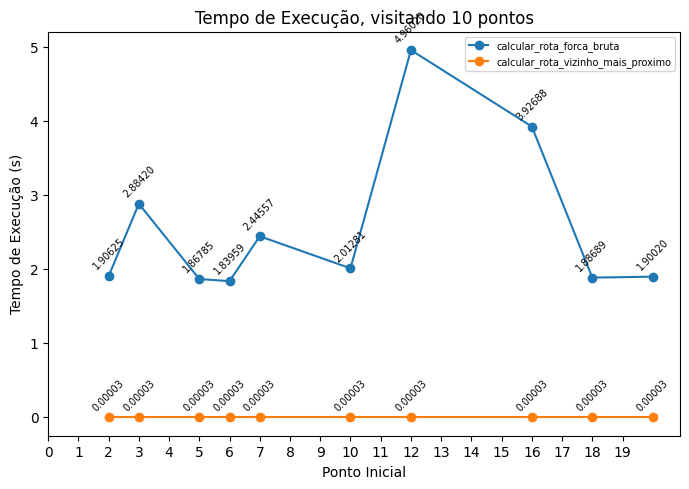

In [ ]:
import matplotlib.pyplot as plt

df_pivot = df_resultados_grupo.pivot(index='ponto_inicial', columns='algoritmo', values=('tempo_execucao'))
ax = df_pivot.plot(kind='line', figsize=(7, 5), marker='o') # Adicionado marker='o'
plt.title(f'Tempo de Execução, visitando {NUMERO_MAXIMO_PONTOS_ANALISE} pontos')
plt.xlabel('Ponto Inicial')
plt.ylabel('Tempo de Execução (s)')
plt.xticks(rotation=0)

# Adiciona os valores aos pontos de dados
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        # Ajuste de formato para exibir 5 casas decimais
        ax.annotate(f'{y:.5f}', (x, y), textcoords="offset points", xytext=(0,5), ha='center', fontsize=7, rotation=45)

# o ponto inicial é um número inteiro, ajustando eixo X para inteiros
ax.set_xticks(range(len(list(pontos_mapa.keys()))))



plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

# o tempo de execução do algoritmo de força bruta sempre é bem maior do que
# ... o tempo de execução do vizinho mais próximo, que garante execução rápida

_______________

In [ ]:
# tabela de comparativo de desempenho do artigo
# ==============================================

df_resultado_menor_distancia = df_resultados\
    .groupby(['qtd_pontos', 'algoritmo', ])\
    .agg({
        'menor_distancia': ['mean'],
    })\
    .reset_index()\
    .droplevel(1, axis=1)\
    .pivot(index='qtd_pontos', columns='algoritmo', values='menor_distancia')\
    .reset_index()\
    .rename(columns={'calcular_rota_forca_bruta': 'forca_bruta_menor_distancia', 'calcular_rota_vizinho_mais_proximo': 'vizinho_mais_proximo_menor_distancia'})

# calcula a diferença percentual entre o algoritmo de vizinho mais próximo sobre o força bruta
df_resultado_menor_distancia['diff_percentual_menor_distancia'] = (df_resultado_menor_distancia['vizinho_mais_proximo_menor_distancia'] / df_resultado_menor_distancia['forca_bruta_menor_distancia']) - 1
df_resultado_menor_distancia


df_resultado_tempo_execucao = df_resultados\
    .groupby(['qtd_pontos', 'algoritmo', ])\
    .agg({
        'tempo_execucao': ['mean'],
    })\
    .reset_index()\
    .droplevel(1, axis=1)\
    .pivot(index='qtd_pontos', columns='algoritmo', values='tempo_execucao')\
    .reset_index()\
    .rename(columns={'calcular_rota_forca_bruta': 'forca_bruta_tempo_execucao', 'calcular_rota_vizinho_mais_proximo': 'vizinho_mais_proximo_tempo_execucao'})

# calcula a diferença percentual entre o algoritmo de vizinho mais próximo sobre o força bruta
df_resultado_tempo_execucao['diff_percentual_tempo_execucao'] = (df_resultado_tempo_execucao['forca_bruta_tempo_execucao'] / df_resultado_tempo_execucao['vizinho_mais_proximo_tempo_execucao']) - 1
df_resultado_tempo_execucao

# unificando
df_resultado_comparativo = df_resultado_menor_distancia.merge(df_resultado_tempo_execucao, on='qtd_pontos').reset_index()
df_resultado_comparativo[['qtd_pontos', 'forca_bruta_menor_distancia', 'forca_bruta_tempo_execucao', 'vizinho_mais_proximo_menor_distancia', 'vizinho_mais_proximo_tempo_execucao', 'diff_percentual_menor_distancia', 'diff_percentual_tempo_execucao']]

algoritmo,qtd_pontos,forca_bruta_menor_distancia,forca_bruta_tempo_execucao,vizinho_mais_proximo_menor_distancia,vizinho_mais_proximo_tempo_execucao,diff_percentual_menor_distancia,diff_percentual_tempo_execucao
0,2,0.15891,0.00007,0.15891,0.00003,0.00000,1.60000
1,3,0.16009,0.00002,0.16009,0.00002,0.00000,0.40000
2,4,0.22851,0.00002,0.23392,0.00001,0.02370,1.00000
3,5,0.22959,0.00118,0.23373,0.00001,0.01801,97.66667
4,6,0.22972,0.00058,0.23187,0.00001,0.00936,57.00000
5,7,0.23191,0.00276,0.23481,0.00001,0.01250,192.00000
6,8,0.23191,0.02326,0.24041,0.00002,0.03665,1093.64706
7,9,0.23814,0.18919,0.26342,0.00002,0.10615,9458.55556
8,10,0.24377,2.56304,0.27943,0.00003,0.14627,85433.80000


In [ ]:
# plotando mapas aleatoriamente com 10 pontos
plotar_rota_no_mapa(pontos_mapa, [18, 16, 12, 10, 6, 5, 7, 20, 2, 3, 18])

In [ ]:
plotar_rota_no_mapa(pontos_mapa, [7, 5, 20, 2, 3, 6, 10, 12, 16, 18, 7])